# TPE Hyperparameter Optimization of CNN - Hyperopt

In this notebook, we will use **TPE driven Bayesian Optimization** to select the best **hyperparameters** for a CNN that recognizes digits in images, using the MNIST dataset and the open source Python package [Hyperopt](http://hyperopt.github.io/hyperopt/).

The MNIST dataset is availale in [Kaggle](https://www.kaggle.com/c/digit-recognizer/data).


## Download dataset

- Navigate to the [MNIST website in Kaggle](https://www.kaggle.com/c/digit-recognizer/data)
- Download the train.csv file
- Unzip and copy the train.csv file to where you see the SAVE_DATASETS-HERE.txt file
- Rename to mnist.csv

**Remember that you need to be logged in to be able to download the dataset**

## Notebook content

- Data Preparation
- Set up the hyperparameter search shape
- Set up a simple CNN
- Set up the objective function
- Perform Bayesian Optimization
- Evaluate Model Performance

In [1]:
# For reproducible results.
# See: 
# https://keras.io/getting_started/faq/#how-can-i-obtain-reproducible-results-using-keras-during-development

import os
os.environ['PYTHONHASHSEED'] = '0'

import numpy as np
import tensorflow as tf
import random as python_random

# The below is necessary for starting Numpy generated random numbers
# in a well-defined initial state.
np.random.seed(123)

# The below is necessary for starting core Python generated random numbers
# in a well-defined state.
python_random.seed(123)

# The below set_seed() will make random number generation
# in the TensorFlow backend have a well-defined initial state.
# For further details, see:
# https://www.tensorflow.org/api_docs/python/tf/random/set_seed
tf.random.set_seed(1234)

In [2]:
import itertools
from functools import partial

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [3]:
from keras.callbacks import ReduceLROnPlateau
from keras.layers import Dense, Flatten, Conv2D, MaxPool2D
from keras.models import Sequential, load_model
from keras.optimizers import Adam

from tensorflow.keras.utils import to_categorical

In [4]:
from hyperopt import hp, tpe, fmin, Trials

#  Data Preparation

The dataset contains information about images, each image is a hand-written digit. The aim is to have the computer predict which digit was written by the person, automatically, by "looking" at the image. 

Each image is 28 pixels in height and 28 pixels in width (28 x 28), making a total of 784 pixels. Each pixel value is an integer between 0 and 255, indicating the darkness in a gray-scale of that pixel.

The data is stored in a dataframe where each each pixel is a column (so it is flattened and not in the 28 x 28 format). 

The data set the has 785 columns. The first column, called "label", is the digit that was drawn by the user. The rest of the columns contain the pixel-values of the associated image.

In [5]:
# Load the data

data = pd.read_csv("../mnist.csv")

# first column is the target, the rest of the columns
# are the pixels of the image

# each row is 1 image
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
# split dataset into a train and test set

X_train, X_test, y_train, y_test = train_test_split(
    data.drop(['label'], axis=1), # the images
    data['label'], # the target
    test_size = 0.1,
    random_state=0)

X_train.shape, X_test.shape

((37800, 784), (4200, 784))

Text(0, 0.5, 'Number of images')

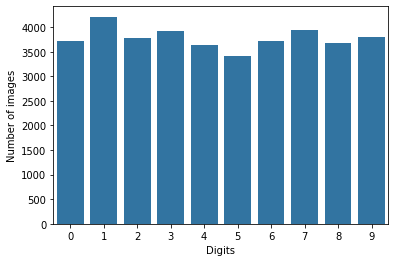

In [7]:
# number of images for each digit

g = sns.countplot(x=y_train)
plt.xlabel('Digits')
plt.ylabel('Number of images')

There are roughly the same amount of images for each of the 10 digits.

## Image re-scaling

We re-scale data for the CNN, between 0 and 1.

In [8]:
# Re-scale the data

# 255 is the maximum value a pixel can take

X_train = X_train / 255
X_test = X_test / 255

## Reshape

The images were stored in a pandas dataframe as 1-D vectors of 784 values. For a CNN with Keras, we need tensors with the following dimensions: width x height x channel. 

Thus, we reshape all data to 28 x 2 8 x 1, 3-D matrices. 

The 3rd dimension corresponds to the channel. RGB images have 3 channels. MNIST images are in gray-scale, thus they have only one channel in the 3rd dimension.

In [9]:
# Reshape image in 3 dimensions:
# height: 28px X width: 28px X channel: 1 

X_train = X_train.values.reshape(-1,28,28,1)
X_test = X_test.values.reshape(-1,28,28,1)

## Target encoding

In [10]:
# the target is 1 variable with the 9 different digits
# as values

y_train.unique()

array([2, 0, 7, 4, 3, 5, 9, 6, 8, 1], dtype=int64)

In [11]:
# For Keras, we need to create 10 dummy variables,
# one for each digit

# Encode labels to one hot vectors (ex : digit 2 -> [0,0,1,0,0,0,0,0,0,0])

y_train = to_categorical(y_train, num_classes = 10)
y_test = to_categorical(y_test, num_classes = 10)

# the new target
y_train

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

Let's print some example images.

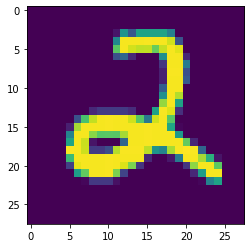

In [12]:
# Some image examples 

g = plt.imshow(X_train[0][:,:,0])

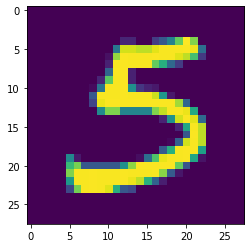

In [13]:
# Some image examples 

g = plt.imshow(X_train[10][:,:,0])

# Define the Hyperparameter Space

Hyperopt provides the hp module to create distributions to sample the hyperparameters. More details in [Defining a Search Space](http://hyperopt.github.io/hyperopt/getting-started/search_spaces/).


We want to find the following hyper-parameters:

- The learning rate of the optimizer.
- The number of convolutional layers.
- The number of fully-connected Dense layers.
- The number of nodes (neurons) for each of the dense layers.
- Whether to use 'sigmoid' or 'relu' activation in all the layers.

In [14]:
# determine the hyperparameter space

param_grid = {
    'learning_rate': hp.uniform('learning_rate', 1e-6, 1e-2),
    'num_conv_layers': hp.quniform('num_conv_layers', 1, 3, 1),
    'num_dense_layers': hp.quniform('num_dense_layers', 1, 5, 1),
    'num_dense_nodes': hp.quniform('num_dense_nodes', 5, 512, 1),
    'activation': hp.choice('activation', ['relu', 'sigmoid']),
}

# Define the CNN

We will create a CNN, with 2 Convolutional layers followed by Pooling, and varying number of fully-connected Dense layers. Each Convlutional layer, can itself have more than 1 conv layer.

In [15]:
# function to create the CNN

def create_cnn(
    # the hyperparam to optimize are passed
    # as arguments
    learning_rate,
    num_conv_layers,
    num_dense_layers,
    num_dense_nodes,
    activation,
):
    """
    Hyper-parameters:
    learning_rate:        Learning-rate for the optimizer.
    convolutional layers: Number of conv layers.
    num_dense_layers:     Number of dense layers.
    num_dense_nodes:      Number of nodes in each dense layer.
    activation:           Activation function for all layers.
    """

    # Start construction of a Keras Sequential model.
    model = Sequential()

    # First convolutional layer.
    # There are many hyper-parameters in this layer
    # For this demo, we will optimize the activation function and
    # the number of convolutional layers that it can take.
    
    # We add the different number of conv layers in the following loop:
    
    for i in range(num_conv_layers):
        model.add(Conv2D(kernel_size=5, strides=1, filters=16, padding='same',
                         activation=activation))
    model.add(MaxPool2D(pool_size=2, strides=2))

    # Second convolutional layer.
    # Same hyperparameters to optimize as previous layer.
    for i in range(num_conv_layers):
        model.add(Conv2D(kernel_size=5, strides=1, filters=36, padding='same',
                         activation=activation))
    model.add(MaxPool2D(pool_size=2, strides=2))

    # Flatten the 4-rank output of the convolutional layers
    # to 2-rank that can be input to a fully-connected Dense layer.
    model.add(Flatten())

    # Add fully-connected Dense layers.
    # The number of layers is a hyper-parameter we want to optimize.
    # We add the different number of layers in the following loop:
    
    for i in range(num_dense_layers):
        
        # Add the dense fully-connected layer to the model.
        # This has two hyper-parameters we want to optimize:
        # The number of nodes (neurons) and the activation function.
        model.add(Dense(num_dense_nodes,
                        activation=activation,
                        ))

    # Last fully-connected dense layer with softmax-activation
    # for use in classification.
    model.add(Dense(10, activation='softmax'))

    # Use the Adam method for training the network.
    # We want to find the best learning-rate for the Adam method.
    optimizer = Adam(learning_rate=learning_rate)

    # In Keras we need to compile the model so it can be trained.
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

# Define the Objective Function

In [16]:
# we will save the model with this name
path_best_model = 'cnn_model.keras'

# starting point for the optimization
best_accuracy = 0

In [17]:
def objective(params):
    
    """
    Hyper-parameters:
    learning_rate:        Learning-rate for the optimizer.
    convolutional layers: Number of conv layers.
    num_dense_layers:     Number of dense layers.
    num_dense_nodes:      Number of nodes in each dense layer.
    activation:           Activation function for all layers.
    """

    # Print the hyper-parameters.        
    print('learning rate: ', params['learning_rate'])
    print('num_conv_layers: ', int(params['num_conv_layers']))
    print('num_dense_layers: ',int(params['num_dense_layers']))
    print('num_dense_nodes: ', int(params['num_dense_nodes']))
    print('activation: ', params['activation'])
    print()
    
    # Create the neural network with the hyper-parameters.
    # We call the function we created previously.
    model = create_cnn(learning_rate=params['learning_rate'],
                       num_conv_layers=int(params['num_conv_layers']),
                       num_dense_layers=int(params['num_dense_layers']),
                       num_dense_nodes=int(params['num_dense_nodes']),
                       activation=params['activation'],
                       )

   
    # Set a learning rate annealer
    # this reduces the learning rate if learning does not improve
    # for a certain number of epochs
    learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', 
                                                patience=2, 
                                                verbose=1, 
                                                factor=0.5, 
                                                min_lr=0.00001)
   
    # train the model
    # we use 3 epochs to be able to run the notebook in a "reasonable"
    # time. If we increase the epochs, we will have better performance
    # this could be another parameter to optimize in fact.
    history = model.fit(x=X_train,
                        y=y_train,
                        epochs=3,
                        batch_size=128,
                        validation_split=0.1,
                        callbacks=learning_rate_reduction)

    # Get the classification accuracy on the validation-set
    # after the last training-epoch.
    accuracy = history.history['val_accuracy'][-1]

    # Print the classification accuracy.
    print()
    print("Accuracy: {0:.2%}".format(accuracy))
    print()

    # Save the model if it improves on the best-found performance.
    # We use the global keyword so we update the variable outside
    # of this function.
    global best_accuracy

    # If the classification accuracy of the saved model is improved ...
    if accuracy > best_accuracy:
        # Save the new model to harddisk.
        # Training CNNs is costly, so we want to avoid having to re-train
        # the network with the best found parameters. We save it instead
        # as we search for the best hyperparam space.
        model.save(path_best_model)
        
        # Update the classification accuracy.
        best_accuracy = accuracy

    # Delete the Keras model with these hyper-parameters from memory.
    del model

    
    # Remember that hyperopt always minimizes the objective
    # function, so we need to negate the accuracy (because we want
    # the maximum accuracy)
    return -accuracy

## Test run

In [18]:
# Before we run the hyper-parameter optimization,
# let's first check that the everything is working
# by passing some default hyper-parameters.

default_parameters = {
    'learning_rate': 1e-5,
    'num_conv_layers': 1,
    'num_dense_layers': 1,
    'num_dense_nodes': 16,
    'activation': 'relu',
}


objective(default_parameters)

learning rate:  1e-05
num_conv_layers:  1
num_dense_layers:  1
num_dense_nodes:  16
activation:  relu

Epoch 1/3
266/266 ━━━━━━━━━━━━━━━━━━━━ 38s 104ms/step - accuracy: 0.1576 - loss: 2.2785 - val_accuracy: 0.3574 - val_loss: 2.2069 - learning_rate: 1.0000e-05
Epoch 2/3
266/266 ━━━━━━━━━━━━━━━━━━━━ 44s 112ms/step - accuracy: 0.4061 - loss: 2.1775 - val_accuracy: 0.4870 - val_loss: 2.0713 - learning_rate: 1.0000e-05
Epoch 3/3
266/266 ━━━━━━━━━━━━━━━━━━━━ 27s 101ms/step - accuracy: 0.4951 - loss: 2.0236 - val_accuracy: 0.5143 - val_loss: 1.8627 - learning_rate: 1.0000e-05

Accuracy: 51.43%



-0.5142857432365417

We obtained a mediocre accuracy, but all our code is working. So let's get started with the Optimization now!!

## Bayesian Optimization with TPE

In [19]:
# fmin performs the minimization
# tpe.suggest samples the parameters following tpe

# with default parameters for TPE
trials = Trials()

search = fmin(
    fn=objective,
    space=param_grid,
    max_evals=30,
    rstate=np.random.default_rng(42),
    algo=tpe.suggest,  # tpe
    trials=trials
)

learning rate:                                                                                                         
0.006517772255089191                                                                                                   
num_conv_layers:                                                                                                       
3                                                                                                                      
num_dense_layers:                                                                                                      
3                                                                                                                      
num_dense_nodes:                                                                                                       
418                                                                                                                    
activation:                             

126/266 ━━━━━━━━━━━━━━━━━━━━ 47s 342ms/step - accuracy: 0.1064 - loss: 2.4609        
127/266 ━━━━━━━━━━━━━━━━━━━━ 47s 342ms/step - accuracy: 0.1064 - loss: 2.4599        
128/266 ━━━━━━━━━━━━━━━━━━━━ 47s 342ms/step - accuracy: 0.1064 - loss: 2.4590        
129/266 ━━━━━━━━━━━━━━━━━━━━ 46s 341ms/step - accuracy: 0.1064 - loss: 2.4580        
130/266 ━━━━━━━━━━━━━━━━━━━━ 46s 342ms/step - accuracy: 0.1064 - loss: 2.4571        
131/266 ━━━━━━━━━━━━━━━━━━━━ 46s 342ms/step - accuracy: 0.1065 - loss: 2.4562        
132/266 ━━━━━━━━━━━━━━━━━━━━ 45s 342ms/step - accuracy: 0.1065 - loss: 2.4553        
133/266 ━━━━━━━━━━━━━━━━━━━━ 45s 342ms/step - accuracy: 0.1065 - loss: 2.4544        
134/266 ━━━━━━━━━━━━━━━━━━━━ 45s 342ms/step - accuracy: 0.1065 - loss: 2.4535        
135/266 ━━━━━━━━━━━━━━━━━━━━ 44s 342ms/step - accuracy: 0.1066 - loss: 2.4526        
136/266 ━━━━━━━━━━━━━━━━━━━━ 44s 342ms/step - accuracy: 0.1066 - loss: 2.4518        
137/266 ━━━━━━━━━━━━━━━━━━━━ 44s 342ms/step - accuracy

262/266 ━━━━━━━━━━━━━━━━━━━━ 1s 453ms/step - accuracy: 0.1075 - loss: 2.3913        
263/266 ━━━━━━━━━━━━━━━━━━━━ 1s 454ms/step - accuracy: 0.1075 - loss: 2.3910        
264/266 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.1075 - loss: 2.3908        
265/266 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.1075 - loss: 2.3905        
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.1075 - loss: 2.3902        
266/266 ━━━━━━━━━━━━━━━━━━━━ 135s 481ms/step - accuracy: 0.1075 - loss: 2.3900 - val_accuracy: 0.1037 - val_loss: 2.3024 - learning_rate: 0.0065

Epoch 2/3                                                                                                              

  1/266 ━━━━━━━━━━━━━━━━━━━━ 1:06:38 15s/step - accuracy: 0.0547 - loss: 2.3019               
  2/266 ━━━━━━━━━━━━━━━━━━━━ 2:27 560ms/step - accuracy: 0.0605 - loss: 2.3031                
  3/266 ━━━━━━━━━━━━━━━━━━━━ 2:32 579ms/step - accuracy: 0.0664 - loss: 2.3031               
  4/266 ━━━━━━━━━━━━━━━━

130/266 ━━━━━━━━━━━━━━━━━━━━ 1:12 536ms/step - accuracy: 0.1056 - loss: 2.3018      
131/266 ━━━━━━━━━━━━━━━━━━━━ 1:12 535ms/step - accuracy: 0.1056 - loss: 2.3018      
132/266 ━━━━━━━━━━━━━━━━━━━━ 1:11 534ms/step - accuracy: 0.1057 - loss: 2.3018      
133/266 ━━━━━━━━━━━━━━━━━━━━ 1:10 532ms/step - accuracy: 0.1057 - loss: 2.3018      
134/266 ━━━━━━━━━━━━━━━━━━━━ 1:10 531ms/step - accuracy: 0.1058 - loss: 2.3018      
135/266 ━━━━━━━━━━━━━━━━━━━━ 1:09 529ms/step - accuracy: 0.1058 - loss: 2.3018      
136/266 ━━━━━━━━━━━━━━━━━━━━ 1:08 528ms/step - accuracy: 0.1058 - loss: 2.3018      
137/266 ━━━━━━━━━━━━━━━━━━━━ 1:07 527ms/step - accuracy: 0.1059 - loss: 2.3018      
138/266 ━━━━━━━━━━━━━━━━━━━━ 1:07 526ms/step - accuracy: 0.1059 - loss: 2.3018      
139/266 ━━━━━━━━━━━━━━━━━━━━ 1:06 525ms/step - accuracy: 0.1060 - loss: 2.3018      
140/266 ━━━━━━━━━━━━━━━━━━━━ 1:05 524ms/step - accuracy: 0.1060 - loss: 2.3018      
141/266 ━━━━━━━━━━━━━━━━━━━━ 1:05 522ms/step - accuracy: 0.1060 -

266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.1081 - loss: 2.3018        
266/266 ━━━━━━━━━━━━━━━━━━━━ 137s 461ms/step - accuracy: 0.1081 - loss: 2.3018 - val_accuracy: 0.1146 - val_loss: 2.3021 - learning_rate: 0.0065

Epoch 3/3                                                                                                              

  1/266 ━━━━━━━━━━━━━━━━━━━━ 2:09 488ms/step - accuracy: 0.1406 - loss: 2.3017                
  2/266 ━━━━━━━━━━━━━━━━━━━━ 1:37 369ms/step - accuracy: 0.1250 - loss: 2.3032               
  3/266 ━━━━━━━━━━━━━━━━━━━━ 1:39 377ms/step - accuracy: 0.1224 - loss: 2.3032               
  4/266 ━━━━━━━━━━━━━━━━━━━━ 1:41 386ms/step - accuracy: 0.1206 - loss: 2.3033               
  5/266 ━━━━━━━━━━━━━━━━━━━━ 1:40 383ms/step - accuracy: 0.1193 - loss: 2.3033               
  6/266 ━━━━━━━━━━━━━━━━━━━━ 1:40 385ms/step - accuracy: 0.1183 - loss: 2.3033               
  7/266 ━━━━━━━━━━━━━━━━━━━━ 1:36 374ms/step - accuracy: 0.1173 - loss: 2.3032     

...

216/266 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - accuracy: 0.7428 - loss: 0.7347        
217/266 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.7436 - loss: 0.7327        
218/266 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.7443 - loss: 0.7307        
219/266 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.7450 - loss: 0.7288        
220/266 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.7457 - loss: 0.7268        
221/266 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.7464 - loss: 0.7249        
222/266 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.7471 - loss: 0.7230        
223/266 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.7478 - loss: 0.7211        
224/266 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.7484 - loss: 0.7192        
225/266 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.7491 - loss: 0.7173        
226/266 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.7498 - loss: 0.7154        
227/266 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.7505 - l

 84/266 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - accuracy: 0.9751 - loss: 0.0802        
 85/266 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - accuracy: 0.9751 - loss: 0.0802        
 86/266 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - accuracy: 0.9751 - loss: 0.0801        
 87/266 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - accuracy: 0.9751 - loss: 0.0800        
 88/266 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - accuracy: 0.9751 - loss: 0.0799        
 89/266 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - accuracy: 0.9752 - loss: 0.0799        
 90/266 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - accuracy: 0.9752 - loss: 0.0798        
 91/266 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - accuracy: 0.9752 - loss: 0.0797        
 92/266 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - accuracy: 0.9752 - loss: 0.0797        
 93/266 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - accuracy: 0.9752 - loss: 0.0796        
 94/266 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - accuracy: 0.9752 - loss: 0.0796        
 95/266 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - accuracy

220/266 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - accuracy: 0.9767 - loss: 0.0742        
221/266 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - accuracy: 0.9767 - loss: 0.0742        
222/266 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - accuracy: 0.9768 - loss: 0.0742        
223/266 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - accuracy: 0.9768 - loss: 0.0741        
224/266 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - accuracy: 0.9768 - loss: 0.0741        
225/266 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.9768 - loss: 0.0741        
226/266 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.9768 - loss: 0.0740        
227/266 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.9768 - loss: 0.0740        
228/266 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.9768 - loss: 0.0740        
229/266 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.9768 - loss: 0.0740        
230/266 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.9768 - loss: 0.0739        
231/266 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.9768 - l

 88/266 ━━━━━━━━━━━━━━━━━━━━ 21s 119ms/step - accuracy: 0.9839 - loss: 0.0529        
 89/266 ━━━━━━━━━━━━━━━━━━━━ 21s 119ms/step - accuracy: 0.9839 - loss: 0.0529        
 90/266 ━━━━━━━━━━━━━━━━━━━━ 21s 119ms/step - accuracy: 0.9839 - loss: 0.0528        
 91/266 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.9839 - loss: 0.0528        
 92/266 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.9839 - loss: 0.0527        
 93/266 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.9839 - loss: 0.0527        
 94/266 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.9839 - loss: 0.0527        
 95/266 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.9839 - loss: 0.0526        
 96/266 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.9839 - loss: 0.0526        
 97/266 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.9839 - loss: 0.0526        
 98/266 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.9839 - loss: 0.0526        
 99/266 ━━━━━━━━━━━━━━━━━━━━ 19s 119ms/step - accuracy

224/266 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.9838 - loss: 0.0525        
225/266 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.9838 - loss: 0.0525        
226/266 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.9838 - loss: 0.0525        
227/266 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.9838 - loss: 0.0524        
228/266 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.9838 - loss: 0.0524        
229/266 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.9838 - loss: 0.0524        
230/266 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.9838 - loss: 0.0524        
231/266 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.9838 - loss: 0.0524        
232/266 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.9838 - loss: 0.0524        
233/266 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - accuracy: 0.9838 - loss: 0.0524        
234/266 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - accuracy: 0.9838 - loss: 0.0524        
235/266 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - accuracy: 0.9838 - l

In [20]:
# tpe.suggest default parameters:
# https://github.com/hyperopt/hyperopt/blob/master/hyperopt/tpe.py#L781
    
# to override the defo parameters:
# https://github.com/hyperopt/hyperopt/issues/632

In [21]:
# trials = Trials()

# # to override tpe.suggest default parameters
# tpe_modified = partial(tpe.suggest, verbose=False)

# search = fmin(
#     fn=objective,
#     space=param_grid,
#     max_evals=30,
#     rstate=np.random.default_rng(42),
#     algo=tpe_modified,  # tpe
#     trials=trials
# )

# Analyze results

In [22]:
# the best hyperparameters can also be found in
# trials

trials.argmin

{'activation': 0,
 'learning_rate': 0.0010413514363082684,
 'num_conv_layers': 2.0,
 'num_dense_layers': 1.0,
 'num_dense_nodes': 501.0}

In [23]:
results = pd.concat([
    pd.DataFrame(trials.vals),
    pd.DataFrame(trials.results)],
    axis=1,
).sort_values(by='loss', ascending=False).reset_index(drop=True)

results.head()

,activation,learning_rate,num_conv_layers,num_dense_layers,num_dense_nodes,loss,status
0,1,0.009740,1.0,5.0,123.0,-0.099735,ok
1,1,0.008821,1.0,3.0,39.0,-0.099735,ok
2,1,0.008694,1.0,5.0,359.0,-0.099735,ok
3,1,0.009765,2.0,1.0,170.0,-0.103704,ok
4,1,0.004172,1.0,4.0,129.0,-0.114550,ok


Text(0.5, 0, 'Hyperparam combination')

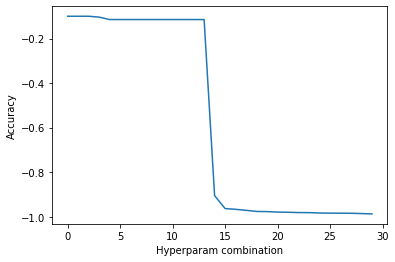

In [24]:
results['loss'].plot()
plt.ylabel('Accuracy')
plt.xlabel('Hyperparam combination')

# Evaluate the model

In [25]:
# load best model

model = load_model(path_best_model)

In [26]:
# make predictions in test set

result = model.evaluate(x=X_test,
                        y=y_test)

132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9866 - loss: 0.0429


In [27]:
# print evaluation metrics

for name, value in zip(model.metrics_names, result):
    print(name, value)

loss 0.04464539885520935
compile_metrics 0.9852380752563477


## Confusion matrix

In [28]:
# Predict the values from the validation dataset
y_pred = model.predict(X_test)

# Convert predictions classes to one hot vectors 
y_pred_classes = np.argmax(y_pred, axis = 1)

# Convert validation observations to one hot vectors
y_true = np.argmax(y_test, axis = 1)

# compute the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes) 

cm

132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


array([[415,   0,   0,   0,   1,   0,   0,   0,   6,   0],
       [  0, 466,   2,   0,   1,   0,   1,   1,   2,   0],
       [  0,   0, 406,   1,   0,   0,   0,   0,   2,   0],
       [  0,   0,   0, 422,   0,   0,   0,   1,   3,   0],
       [  1,   0,   1,   0, 418,   0,   2,   2,   1,   4],
       [  0,   0,   0,   2,   0, 378,   2,   0,   0,   0],
       [  0,   0,   0,   0,   1,   1, 409,   0,   1,   0],
       [  0,   0,   4,   1,   0,   0,   0, 463,   0,   1],
       [  0,   1,   1,   4,   0,   2,   0,   0, 376,   0],
       [  3,   0,   0,   2,   1,   0,   0,   1,   2, 385]], dtype=int64)

Text(0.5, 13.421126458070312, 'Predicted label')

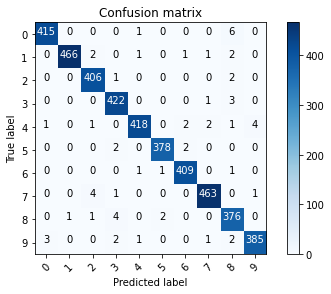

In [29]:
# let's make it more colourful
classes = 10

plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion matrix')
plt.colorbar()
tick_marks = np.arange(classes)
plt.xticks(tick_marks, range(classes), rotation=45)
plt.yticks(tick_marks, range(classes))

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j],
             horizontalalignment="center",
             color="white" if cm[i, j] > 100 else "black",
            )

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')

Here we can see that our CNN performs very well on all digits.